[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hatemphd/MLE_POC/blob/main/TrustGate_SWEBench_PoC_ML_v3.ipynb)
[![Open locally](https://img.shields.io/badge/Open-locally-0F4C5C)](GETTING_STARTED.md)
[![Pipeline docs](https://img.shields.io/badge/Docs-PIPELINE.md-E36414)](PIPELINE.md)
<!-- version-stamp --> **Version** 1.1 · **Released** 2026-09-26 · **Branch** main

**Open in Colab**: runs in the browser. The bootstrap cell below the pip install clones this repository and builds the candidate table in about five minutes; the repository URL is already set. Replace `hatemphd/MLE_POC` in the badge link with this repository's GitHub path.

**Open locally**: clone the repository, run `./setup_and_run.sh --no-run` then `./run_pipeline.sh`, and open the notebook with `./setup_and_run.sh`. Step-by-step instructions in [GETTING_STARTED.md](GETTING_STARTED.md).


# TrustGate × SWE-bench Verified — Machine Learning Study

## Goal

Build a defensible machine-learning study for **TrustGate**:

> Given a GitHub issue, repository state, and a candidate PR patch, estimate the probability that the patch correctly resolves the underlying issue.

The final TrustGate decision is a **three-way gate**:

- **Approve** — high-confidence candidate
- **Human review** — uncertain candidate
- **Reject** — low-confidence candidate

The model should produce a probability first. The three-way decision is then created from thresholds chosen on validation data.

### Important definition

A SWE-bench success label means:

> the candidate patch satisfies the benchmark's issue-linked tests in the benchmark evaluation environment.

That is a useful software-correctness proxy. It is **not** by itself a complete label for production PR safety, code quality, security, maintainability, or organizational approval policy.

### Notebook principles

1. Understand the benchmark before modeling it.
2. Keep benchmark-only information separate from real TrustGate features.
3. Generate candidate-patch labels with the official SWE-bench evaluation environment.
4. Split data by **issue**, not by candidate row.
5. Report discrimination, classification, calibration, and decision metrics.
6. Treat evaluation/environment failures separately from genuine patch failures.
7. Use synthetic candidates only for pipeline smoke tests, not as the main evidence of ML performance.

## 1. SWE-bench Verified in simple English

Imagine 500 real bug reports taken from GitHub.

For each one, SWE-bench tells us:

- **what the user/developer reported** — `problem_statement`
- **which repository** the problem came from — `repo`
- **the exact code state before the fix** — `base_commit`
- **the real patch that fixed it** — `patch`
- **the tests connected to the fix** — `test_patch`
- **which tests are expected to change from failing to passing** — `FAIL_TO_PASS`
- **which tests should continue passing** — `PASS_TO_PASS`
- **how to prepare the repository environment** — `environment_setup_commit`, `version`
- some historical context such as `hints_text` and `created_at`

SWE-bench Verified contains **500 human-validated tasks across 12 Python repositories**.

The key TrustGate transformation is:

```text
GitHub issue + codebase + candidate PR
                  |
                  v
        TrustGate features
                  |
                  v
      probability candidate is correct
                  |
        +---------+---------+
        |         |         |
     APPROVE   HUMAN      REJECT
               REVIEW
```

SWE-bench is valuable because the candidate patch can be executed in a controlled benchmark environment and checked against issue-linked tests.

**Primary source:** SWE-bench official dataset:
https://huggingface.co/datasets/SWE-bench/SWE-bench_Verified

**Princeton-hosted copy:**
https://huggingface.co/datasets/princeton-nlp/SWE-bench_Verified

**Source:** SWE-bench evaluation documentation:
https://github.com/SWE-bench/SWE-bench/blob/main/docs/assets/evaluation.md

## 2. What exactly is in the 500-row dataset?

The current Hugging Face dataset card reports one `test` split with **500 rows** and these fields:

| Field | Plain-English meaning | TrustGate use |
|---|---|---|
| `repo` | GitHub repository | EDA; optional production context |
| `instance_id` | Unique benchmark issue identifier | Grouping/splitting only |
| `base_commit` | Code version before the fix | Benchmark setup |
| `patch` | Reference/gold fix | Label reference only |
| `test_patch` | Tests added/changed by the real fix | Evaluation reference only |
| `problem_statement` | Issue title + issue body | Available to TrustGate |
| `hints_text` | Comments before the solution PR | Historical/context feature only if available |
| `created_at` | PR creation date | Temporal analysis |
| `version` | Evaluation/install version | Environment metadata |
| `FAIL_TO_PASS` | Tests expected to be fixed | Evaluation only; **not a production feature** |
| `PASS_TO_PASS` | Tests expected to stay green | Evaluation only; **not a production feature** |
| `environment_setup_commit` | Commit used to build/install the environment | Evaluation setup |
| `difficulty` | Benchmark difficulty label | EDA only by default |

The dataset card also reports that `repo` has 12 values and that the benchmark has 4 difficulty values.

### Why this matters

A common mistake is to train directly from these 500 rows.

That is too close to the benchmark-task level.

TrustGate makes decisions about **candidate PRs**, so the modeling table should look more like:

```text
issue A + candidate patch 1 -> label 1
issue A + candidate patch 2 -> label 0
issue A + candidate patch 3 -> label 1
issue B + candidate patch 4 -> label 0
...
```

One issue can therefore produce many candidate rows.

**Dataset source:** https://huggingface.co/datasets/princeton-nlp/SWE-bench_Verified

In [1]:
# Analysis dependencies.
# This notebook is designed for Colab/Jupyter.
!pip -q install datasets scikit-learn pandas numpy matplotlib

zsh:1: command not found: pip


In [ ]:
# Google Colab support. Locally this cell does nothing.
#
# On Colab it clones the repository and builds the candidate table by running the
# pipeline right here (about five minutes, plain HTTPS downloads, no Docker).
# That avoids uploading a large CSV by hand.
import os
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO_URL = "https://github.com/hatemphd/MLE_POC.git"
    WORKDIR = "/content/trustgate"
    if not os.path.isdir(WORKDIR):
        get_ipython().system(f"git clone -q {REPO_URL} {WORKDIR}")
    else:
        get_ipython().system(f"git -C {WORKDIR} pull -q --ff-only")   # pick up new commits
    os.chdir(WORKDIR)
    REQUIRED = ["pipeline/select_issues.py", "pipeline/fetch_candidates.py",
                "pipeline/build_candidate_table.py", "pipeline/common.py"]
    missing = [f for f in REQUIRED if not os.path.exists(f)]
    if missing:
        print("Cloned", REPO_URL, "into", WORKDIR, "but it does not contain:", missing)
        print("Contents:", sorted(os.listdir(WORKDIR)))
        print("Push the full project (including the pipeline/ folder) to that URL, then run")
        print("  !rm -rf", WORKDIR)
        print("and rerun this cell.")
    else:
        get_ipython().system("pip -q install pyyaml requests pyarrow pyflakes")
        if not os.path.exists("data/trustgate_candidate_results.csv"):
            get_ipython().system("python pipeline/select_issues.py")
            get_ipython().system("python pipeline/fetch_candidates.py --workers 24")
            get_ipython().system("python pipeline/build_candidate_table.py")
        print("Working directory:", os.getcwd())

    # Alternative if you already have the CSV: mount Drive and point at it.
    #   from google.colab import drive; drive.mount("/content/drive")
    #   os.environ["TRUSTGATE_CANDIDATES"] = "/content/drive/MyDrive/trustgate_candidate_results.csv"


In [2]:
import ast
import json
import math
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Which SWE-bench variant to study. The pipeline reads the same variable, so
# `TRUSTGATE_SPLIT=full ./run_pipeline.sh --split full` and this notebook agree.
#   verified : 500 human-validated issues (default)
#   full     : 2,294 issues, the complete test set
#   lite     : 300 issues
TRUSTGATE_SPLIT = os.environ.get("TRUSTGATE_SPLIT", "verified").lower()
SPLIT_DATASETS = {
    "verified": ("SWE-bench/SWE-bench_Verified", "princeton-nlp/SWE-bench_Verified"),
    "full": ("SWE-bench/SWE-bench", "princeton-nlp/SWE-bench"),
    "lite": ("SWE-bench/SWE-bench_Lite", "princeton-nlp/SWE-bench_Lite"),
}
DATASET_NAME, DATASET_FALLBACK = SPLIT_DATASETS[TRUSTGATE_SPLIT]
print("Split:", TRUSTGATE_SPLIT, "->", DATASET_NAME)

try:
    ds = load_dataset(DATASET_NAME, split="test")
except Exception as official_error:
    # Compatibility with the original Princeton-hosted dataset card.
    print("Official SWE-bench dataset load failed:", official_error)
    DATASET_NAME = DATASET_FALLBACK
    ds = load_dataset(DATASET_NAME, split="test")
swe = ds.to_pandas()

print("Rows:", len(swe))
print("Columns:", swe.columns.tolist())
display(swe.head(3))

Matplotlib is building the font cache; this may take a moment.


README.md:   0%|          | 0.00/3.48k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.30MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Rows: 500
Columns: ['base_commit', 'created_at', 'difficulty', 'environment_setup_commit', 'eval_type', 'image', 'instance_id', 'log_parser', 'repo', 'version', 'patch', 'test_patch', 'eval_script', 'problem_statement', 'hints_text', 'FAIL_TO_PASS', 'PASS_TO_PASS']


,base_commit,created_at,difficulty,environment_setup_commit,eval_type,image,instance_id,log_parser,repo,version,patch,test_patch,eval_script,problem_statement,hints_text,FAIL_TO_PASS,PASS_TO_PASS
0,d16bfe05a744909de4b27f5875fe0d4ed41ce607,2022-03-03T15:14:54Z,15 min - 1 hour,298ccb478e6bf092953bca67a3d29dc6c35f6752,pass_and_fail,swebench/sweb.eval.x86_64.astropy_1776_astropy...,astropy__astropy-12907,parse_log_astropy,astropy/astropy,4.3,diff --git a/astropy/modeling/separable.py b/a...,diff --git a/astropy/modeling/tests/test_separ...,#!/bin/bash\nset -uxo pipefail\nsource /opt/mi...,Modeling's `separability_matrix` does not comp...,,[astropy/modeling/tests/test_separable.py::tes...,[astropy/modeling/tests/test_separable.py::tes...
1,298ccb478e6bf092953bca67a3d29dc6c35f6752,2022-03-31T23:28:27Z,15 min - 1 hour,298ccb478e6bf092953bca67a3d29dc6c35f6752,pass_and_fail,swebench/sweb.eval.x86_64.astropy_1776_astropy...,astropy__astropy-13033,parse_log_astropy,astropy/astropy,4.3,diff --git a/astropy/timeseries/core.py b/astr...,diff --git a/astropy/timeseries/tests/test_sam...,#!/bin/bash\nset -uxo pipefail\nsource /opt/mi...,TimeSeries: misleading exception when required...,The relevant code that produces the misleading...,[astropy/timeseries/tests/test_sampled.py::tes...,[astropy/timeseries/tests/test_sampled.py::tes...
2,6ed769d58d89380ebaa1ef52b300691eefda8928,2022-05-09T14:16:30Z,15 min - 1 hour,cdf311e0714e611d48b0a31eb1f0e2cbffab7f23,pass_and_fail,swebench/sweb.eval.x86_64.astropy_1776_astropy...,astropy__astropy-13236,parse_log_astropy,astropy/astropy,5.0,diff --git a/astropy/table/table.py b/astropy/...,diff --git a/astropy/table/tests/test_mixin.py...,#!/bin/bash\nset -uxo pipefail\nsource /opt/mi...,Consider removing auto-transform of structured...,@mhvk - I'm happy to do this PR if you think i...,[astropy/table/tests/test_mixin.py::test_ndarr...,[astropy/table/tests/test_mixin.py::test_attri...


In [3]:
EXPECTED_COLUMNS = [
    "repo", "instance_id", "base_commit", "patch", "test_patch",
    "problem_statement", "hints_text", "created_at", "version",
    "FAIL_TO_PASS", "PASS_TO_PASS", "environment_setup_commit", "difficulty"
]

missing = [c for c in EXPECTED_COLUMNS if c not in swe.columns]
assert not missing, f"Missing expected columns: {missing}"

print("Unique repositories:", swe["repo"].nunique())
print("Difficulty values:", swe["difficulty"].value_counts(dropna=False).to_dict())
print(
    "Fraction where environment_setup_commit != base_commit:",
    (swe["environment_setup_commit"] != swe["base_commit"]).mean()
)
print("Unique versions:", swe["version"].nunique())
print("Rows with hints:", swe["hints_text"].fillna("").str.len().gt(0).mean())

Unique repositories: 12
Difficulty values: {'15 min - 1 hour': 261, '<15 min fix': 194, '1-4 hours': 42, '>4 hours': 3}
Fraction where environment_setup_commit != base_commit: 0.984
Unique versions: 53
Rows with hints: 0.676


## 3. Benchmark EDA

The first EDA section answers a simple question:

> What does this benchmark actually look like before we ask a model to learn anything?

We look at:

- repository balance
- difficulty balance
- patch size
- issue description size
- test counts
- test-patch size
- relationship between benchmark variables
- missing values
- environment differences

These plots describe the benchmark. They do **not** automatically define the TrustGate feature set.

In [4]:
def parse_list_field(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            value = json.loads(x)
            return value if isinstance(value, list) else [value]
        except Exception:
            # Keep the raw value as one item if it is not valid JSON.
            return [x]
    return []

def unified_diff_stats(patch_text):
    patch_text = patch_text or ""
    lines = patch_text.splitlines()

    additions = sum(
        1 for line in lines
        if line.startswith("+") and not line.startswith("+++")
    )
    deletions = sum(
        1 for line in lines
        if line.startswith("-") and not line.startswith("---")
    )
    files = re.findall(r"^\+\+\+ b/(.+)$", patch_text, flags=re.MULTILINE)
    hunks = len(re.findall(r"^@@", patch_text, flags=re.MULTILINE))

    return {
        "patch_additions": additions,
        "patch_deletions": deletions,
        "patch_files": len(set(files)),
        "patch_hunks": hunks,
        "patch_chars": len(patch_text),
    }

patch_stats = pd.DataFrame(
    [unified_diff_stats(p) for p in swe["patch"].fillna("")]
)

eda = pd.concat(
    [
        swe[
            [
                "instance_id", "repo", "difficulty", "version",
                "created_at", "environment_setup_commit", "base_commit"
            ]
        ].reset_index(drop=True),
        patch_stats.reset_index(drop=True),
    ],
    axis=1,
)

eda["problem_chars"] = swe["problem_statement"].fillna("").str.len().values
eda["problem_lines"] = swe["problem_statement"].fillna("").str.count(r"\n").values + 1
eda["hints_chars"] = swe["hints_text"].fillna("").str.len().values
eda["test_patch_chars"] = swe["test_patch"].fillna("").str.len().values
eda["fail_to_pass_count"] = swe["FAIL_TO_PASS"].map(lambda x: len(parse_list_field(x)))
eda["pass_to_pass_count"] = swe["PASS_TO_PASS"].map(lambda x: len(parse_list_field(x)))
eda["environment_diff"] = (
    swe["environment_setup_commit"] != swe["base_commit"]
).astype(int)

numeric_eda_cols = [
    "patch_additions", "patch_deletions", "patch_files", "patch_hunks",
    "patch_chars", "problem_chars", "problem_lines", "hints_chars",
    "test_patch_chars", "fail_to_pass_count", "pass_to_pass_count",
    "environment_diff"
]

display(eda[numeric_eda_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
patch_additions,500.0,9.944,17.868616,0.0,2.00,4.0,10.00,202.0
patch_deletions,500.0,4.390,8.347770,0.0,1.00,2.0,4.00,89.0
patch_files,500.0,1.246,1.069473,1.0,1.00,1.0,1.00,21.0
patch_hunks,500.0,2.440,3.761742,1.0,1.00,1.0,2.00,45.0
patch_chars,500.0,1587.340,2052.958374,277.0,622.50,885.0,1615.50,17385.0
problem_chars,500.0,1699.732,2048.616217,143.0,643.75,1185.0,2036.00,24770.0
problem_lines,500.0,41.456,43.882975,3.0,13.00,28.0,54.00,378.0
hints_chars,500.0,1097.988,2105.146227,0.0,0.00,251.0,1174.75,15369.0
test_patch_chars,500.0,1784.490,1978.638047,367.0,826.75,1269.5,2027.75,26578.0
fail_to_pass_count,500.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0


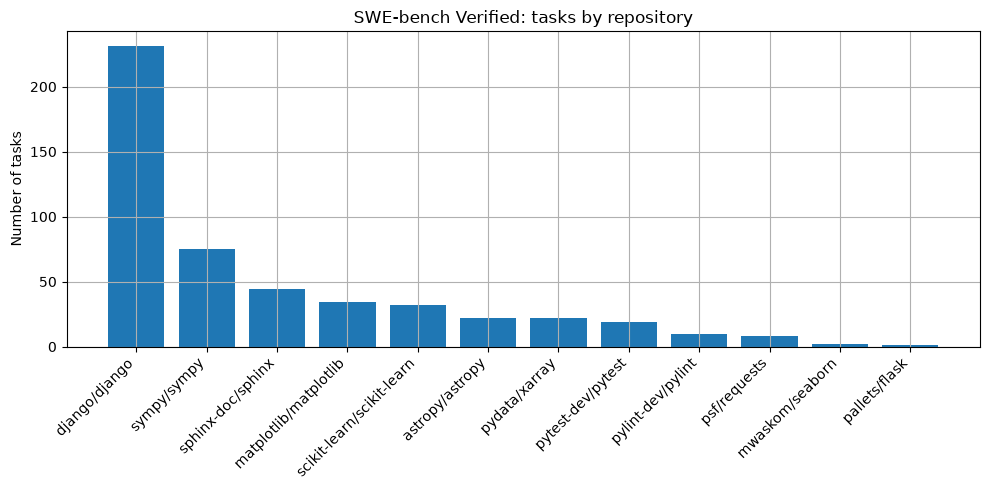

In [5]:
# 3.1 Repository distribution
counts = swe["repo"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values)
plt.title("SWE-bench Verified: tasks by repository")
plt.ylabel("Number of tasks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

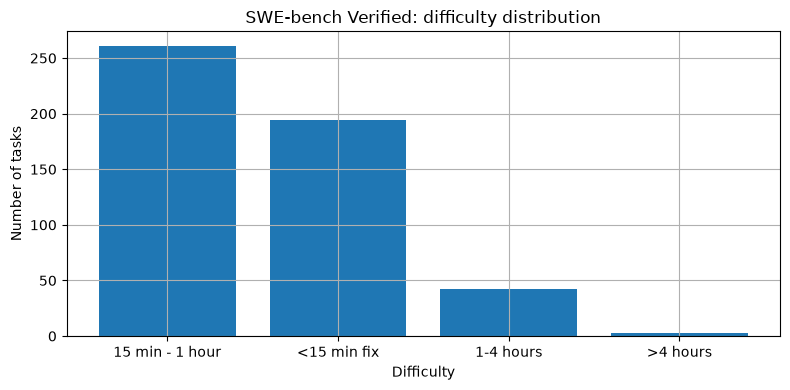

In [6]:
# 3.2 Difficulty distribution
counts = swe["difficulty"].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("SWE-bench Verified: difficulty distribution")
plt.ylabel("Number of tasks")
plt.xlabel("Difficulty")
plt.tight_layout()
plt.show()

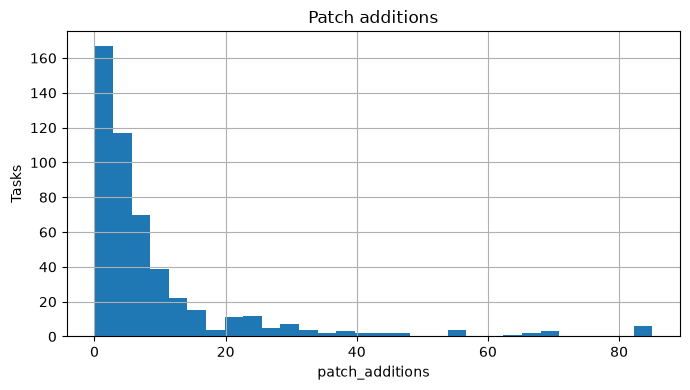

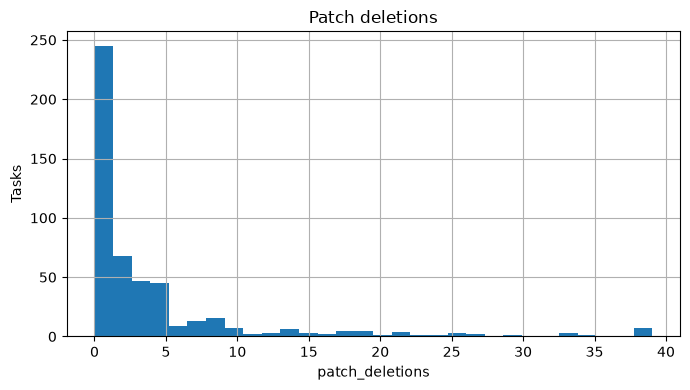

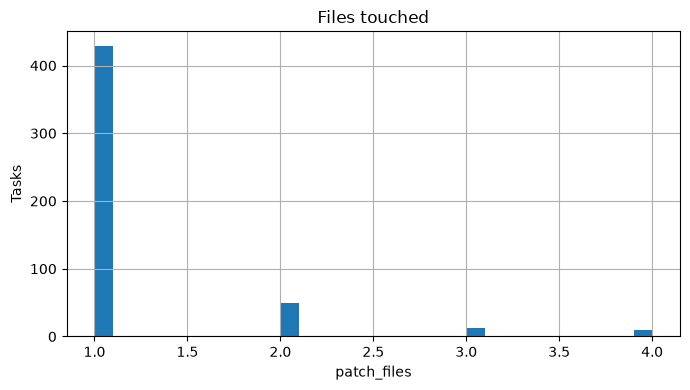

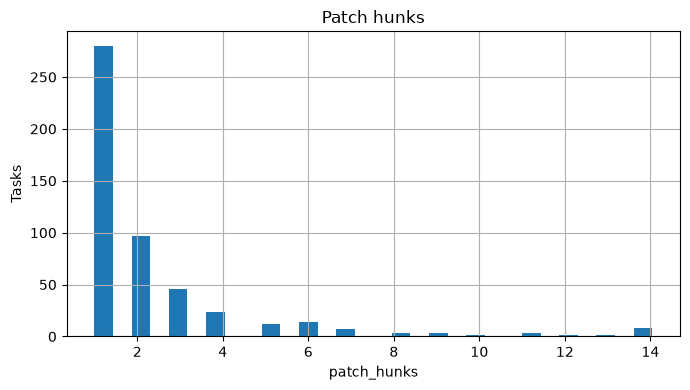

In [7]:
# 3.3 Distribution of patch size
features_to_plot = [
    ("patch_additions", "Patch additions"),
    ("patch_deletions", "Patch deletions"),
    ("patch_files", "Files touched"),
    ("patch_hunks", "Patch hunks"),
]

for col, title in features_to_plot:
    clipped = eda[col].clip(upper=eda[col].quantile(0.99))

    plt.figure(figsize=(7, 4))
    plt.hist(clipped, bins=30)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Tasks")
    plt.tight_layout()
    plt.show()

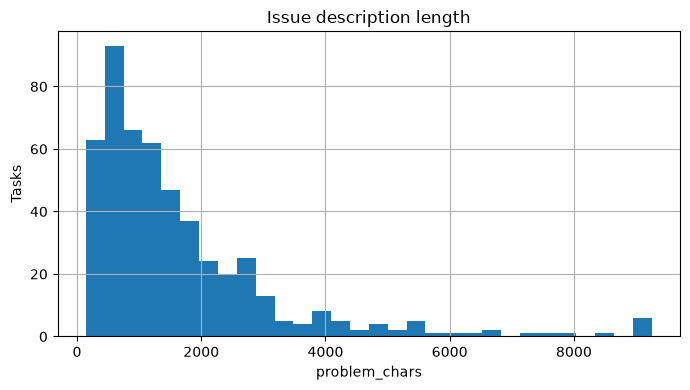

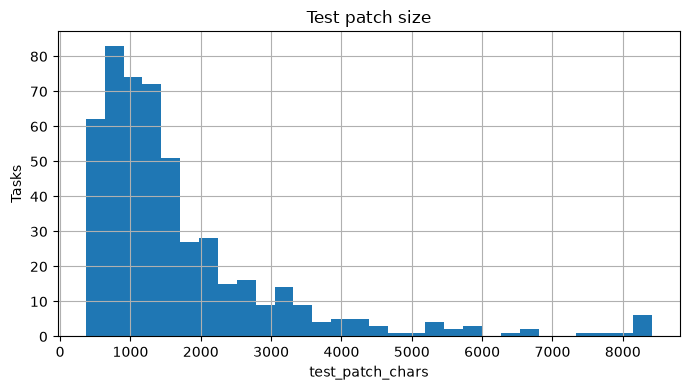

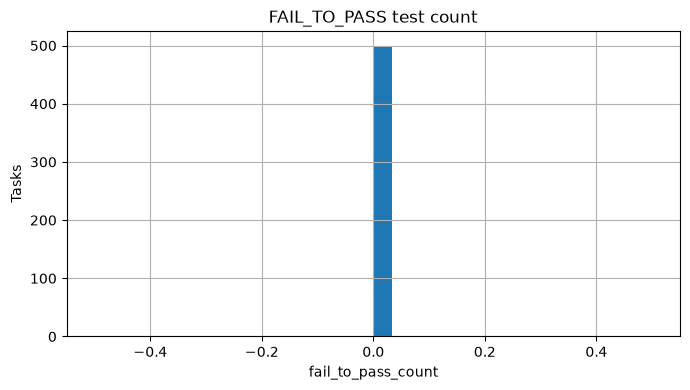

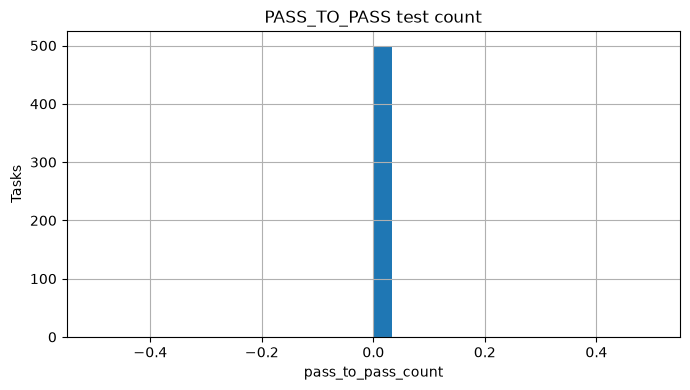

In [8]:
# 3.4 Issue and test complexity distributions
features_to_plot = [
    ("problem_chars", "Issue description length"),
    ("test_patch_chars", "Test patch size"),
    ("fail_to_pass_count", "FAIL_TO_PASS test count"),
    ("pass_to_pass_count", "PASS_TO_PASS test count"),
]

for col, title in features_to_plot:
    clipped = eda[col].clip(upper=eda[col].quantile(0.99))

    plt.figure(figsize=(7, 4))
    plt.hist(clipped, bins=30)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Tasks")
    plt.tight_layout()
    plt.show()

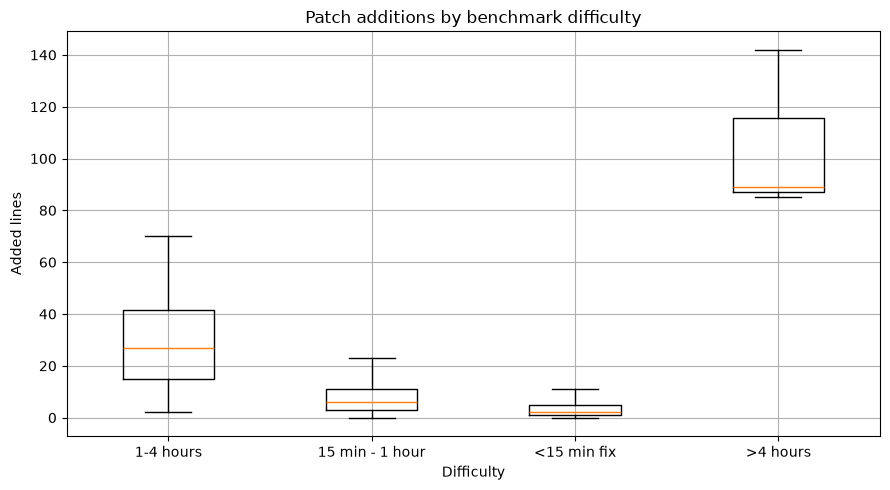

In [9]:
# 3.5 Patch size by difficulty
plot_df = eda.copy()

order = [x for x in ["easy", "medium", "hard", "very hard"] if x in plot_df["difficulty"].astype(str).unique()]
if not order:
    order = sorted(plot_df["difficulty"].astype(str).unique())

groups = [
    plot_df.loc[plot_df["difficulty"].astype(str) == d, "patch_additions"].values
    for d in order
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, tick_labels=order, showfliers=False)
plt.title("Patch additions by benchmark difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Added lines")
plt.tight_layout()
plt.show()

## 4. Heatmap: understand relationships between benchmark variables

The heatmap is useful because several measurements are naturally related.

For example:

- `patch_chars` will usually increase as additions/deletions increase.
- `test_patch_chars` can rise with the size of the change.
- issue length and patch complexity may or may not be related.
- test counts tell us about the verification footprint of the task.

A high correlation does **not** mean one variable causes another. It tells us that the two measurements move together.

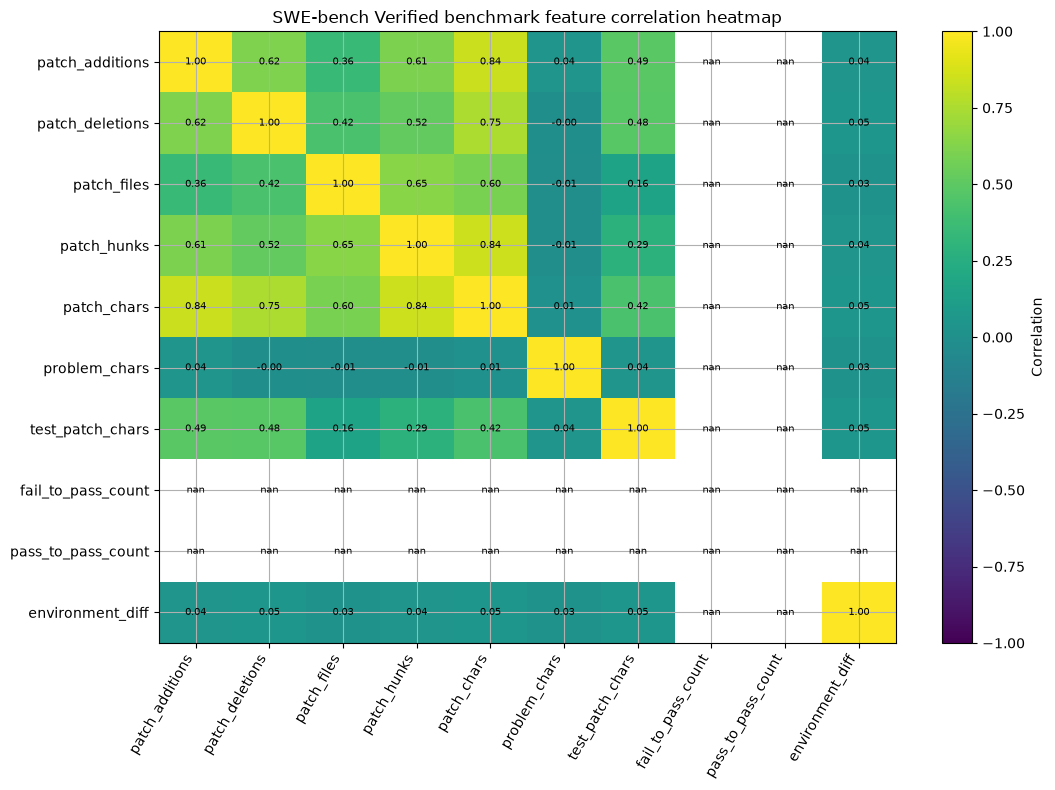

In [10]:
heat_cols = [
    "patch_additions", "patch_deletions", "patch_files", "patch_hunks",
    "patch_chars", "problem_chars", "test_patch_chars",
    "fail_to_pass_count", "pass_to_pass_count", "environment_diff"
]

corr = eda[heat_cols].corr()

plt.figure(figsize=(11, 8))
im = plt.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(heat_cols)), heat_cols, rotation=60, ha="right")
plt.yticks(range(len(heat_cols)), heat_cols)
plt.title("SWE-bench Verified benchmark feature correlation heatmap")

for i in range(len(heat_cols)):
    for j in range(len(heat_cols)):
        plt.text(
            j, i, f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=7
        )

plt.tight_layout()
plt.show()

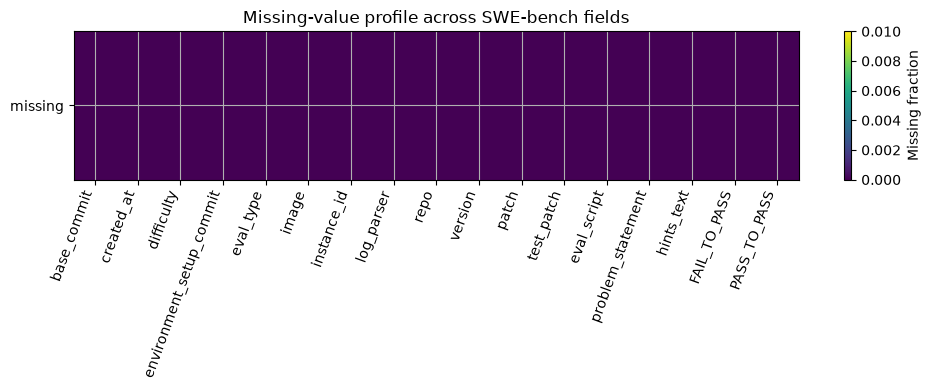

,missing_fraction
base_commit,0.0
created_at,0.0
difficulty,0.0
environment_setup_commit,0.0
eval_type,0.0
image,0.0
instance_id,0.0
log_parser,0.0
repo,0.0
version,0.0


In [11]:
# 4.2 Missing-value heatmap
missing_rate = swe.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
im = plt.imshow(
    missing_rate.values.reshape(1, -1),
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=max(0.01, float(missing_rate.max())),
)
plt.colorbar(im, label="Missing fraction")
plt.xticks(range(len(missing_rate)), missing_rate.index, rotation=70, ha="right")
plt.yticks([0], ["missing"])
plt.title("Missing-value profile across SWE-bench fields")
plt.tight_layout()
plt.show()

display(missing_rate.to_frame("missing_fraction"))

## 5. What should become a TrustGate feature?

This is the most important modeling idea in the notebook.

A **feature** is simply a measurable signal that the model can see when it is judging a candidate PR.

Think of a feature as one answer to one small question.

### A. Patch size and shape

- `patch_additions` — how many lines were added?
- `patch_deletions` — how many lines were removed?
- `patch_files` — how many files changed?
- `patch_hunks` — how many separate change blocks?
- `patch_chars` — how large is the patch as text?

Plain English:

> Is this a small, focused change or a large, spread-out change?

These are safe starting features because they can be computed directly from the candidate diff.

### B. Issue size and wording

- `problem_chars`
- `problem_lines`
- optional later: issue token count
- optional later: TF-IDF/embedding representation

Plain English:

> How much information is in the issue, and what kind of issue is it?

### C. Patch/code health checks

These are highly valuable when available:

- `patch_apply_ok`
- `syntax_ok`
- `compile_ok`
- `lint_warning_count`
- `static_error_count`
- `undefined_name_count`
- `import_error_count`

Plain English:

> Does the changed code still look structurally healthy?

### D. Test/CI evidence available before the decision

Examples:

- `visible_test_pass_rate`
- `visible_test_fail_count`
- `ci_job_failure_count`
- `ci_job_success_rate`

Plain English:

> What does the testing and CI system say about the candidate so far?

These are legitimate production features when the corresponding results are genuinely available at decision time.

### E. Independent-agent consistency

If several independent coding attempts are generated for the same issue:

- patch similarity
- same files touched
- same key symbols changed
- agreement on the affected area

Plain English:

> Do different attempts independently arrive at similar changes?

This is much stronger than assigning a confidence number by hand.

### F. Real model confidence

You may use model-generated confidence **only when it is the actual confidence output of the model**, not a number assigned after we know whether the patch succeeded.

Plain English:

> How sure was the generating system before seeing the answer?

### Features that are useful for EDA but should NOT be predictors

Never train TrustGate on:

- the gold/reference patch
- gold touched files
- `FAIL_TO_PASS`
- `PASS_TO_PASS`
- hidden SWE-bench test outcomes
- `resolved_status`
- manually assigned confidence based on success/failure
- any information created after the TrustGate decision

Those fields contain the answer or information too close to the answer.

In [12]:
# Candidate-level dataset schema.
#
# One row = one candidate patch for one SWE-bench issue.
#
# This file does not exist until candidate patches have been generated
# and evaluated with the official SWE-bench harness.

CANDIDATE_COLUMNS = [
    "instance_id",
    "candidate_id",
    "agent_name",
    "model_name",
    "temperature",
    "patch",
    "patch_apply_ok",
    "syntax_ok",
    "compile_ok",
    "lint_warning_count",
    "static_error_count",
    "undefined_name_count",
    "import_error_count",
    "visible_test_pass_rate",
    "visible_test_fail_count",
    "ci_job_failure_count",
    "ci_job_success_rate",
    "self_consistency",
    "model_confidence",
    "resolved_status",          # FULL / PARTIAL / NO
    "fail_to_pass_rate",       # evaluation/diagnostic field
    "pass_to_pass_rate",       # evaluation/diagnostic field
    "evaluation_error",
    "label",                   # 1 only for FULL, 0 for PARTIAL/NO
]

candidate_template = pd.DataFrame(columns=CANDIDATE_COLUMNS)
display(candidate_template)

,instance_id,candidate_id,agent_name,model_name,temperature,patch,patch_apply_ok,syntax_ok,compile_ok,lint_warning_count,...,visible_test_fail_count,ci_job_failure_count,ci_job_success_rate,self_consistency,model_confidence,resolved_status,fail_to_pass_rate,pass_to_pass_rate,evaluation_error,label


## 6. Candidate labels: how the ground truth is created

> **In this repository** the candidate labels come from the public SWE-bench leaderboard: `./run_pipeline.sh` downloads the patches that submitted systems produced for each issue together with the official harness `report.json`, and writes `data/trustgate_candidate_results.csv`. See `PIPELINE.md`. The text below describes how those labels were originally created and how to regrade them yourself.

For the ML dataset, generate **real candidate patches** for SWE-bench issues.

Each candidate should be evaluated with the official SWE-bench harness.

The recommended target is:

```text
label = 1  -> FULL
label = 0  -> PARTIAL or NO
```

Keep `FULL / PARTIAL / NO` as the detailed status.

### Critical rule

An environment/evaluation failure is **not automatically label 0**.

For example:

```text
Patch is valid
      +
Docker image fails to build
      =
environment failure
```

That is different from:

```text
Patch applies
      +
tests genuinely fail
      =
candidate failure
```

The data pipeline should keep those cases separate.

### Official evaluation

The current SWE-bench tooling supports evaluating the verified benchmark and also verifying gold patches.

Examples from the current SWE-bench documentation:

```bash
swebench eval verified --gold -i <instance_id> --run-id validate-gold

swebench eval verified -p <predictions.jsonl> --run-id <run_id> -j 8
```

The official harness uses Docker-based task environments and can also run through Modal.

Source:
https://github.com/SWE-bench/SWE-bench/blob/main/docs/reference/harness.md

Source:
https://github.com/SWE-bench/SWE-bench/blob/main/docs/guides/quickstart.md

In [13]:
# Example candidate prediction format expected by the SWE-bench harness.
example_prediction = {
    "instance_id": "owner__repo-1234",
    "model_patch": "diff --git a/example.py b/example.py\n...",
    "model_name_or_path": "TrustGate-Agent-v1",
}

print(json.dumps(example_prediction, indent=2))

{
  "instance_id": "owner__repo-1234",
  "model_patch": "diff --git a/example.py b/example.py\n...",
  "model_name_or_path": "TrustGate-Agent-v1"
}


## 7. Docker: where it belongs

Docker is important for **label generation**, not for pandas/scikit-learn.

Use this separation:

```text
                SWE-bench issue
                       |
             generate candidate patch
                       |
                       v
          Docker / SWE-bench harness
                       |
             execute + grade patch
                       |
                       v
                 real label
                       |
                       v
             candidate feature table
                       |
                       v
                  Colab/Python
             EDA + ML + evaluation
```

### Why Docker?

SWE-bench tasks come from different repositories and historical environments.

The official harness uses Docker to create reproducible task environments, isolate dependencies, apply the candidate patch, run tests, and grade the result.

Current SWE-bench documentation recommends roughly **120 GB free storage** and **16 GB+ RAM** for local evaluation.

For larger runs, Modal is an alternative supported by the harness.

### Recommendation

- Use **Docker or Modal** to create trustworthy candidate labels.
- Use **Colab/Jupyter/Python** for EDA, feature engineering, modeling, calibration, and evaluation.

## 8. Candidate-level EDA

Once the candidate table is populated, the most useful EDA asks:

> What characteristics are associated with successful vs unsuccessful candidate patches?

The same issue can have multiple candidate rows, so the plots below are candidate-level plots but the statistical split must still be issue-level.

In [ ]:
def add_diff_features(candidates):
    if candidates.empty:
        return candidates.copy()

    feats = pd.DataFrame(
        [unified_diff_stats(p) for p in candidates["patch"].fillna("")]
    )

    out = pd.concat(
        [
            candidates.reset_index(drop=True),
            feats.reset_index(drop=True)
        ],
        axis=1,
    )

    return out

# Candidate table produced by the pipeline (see PIPELINE.md):
#   ./run_pipeline.sh  ->  data/trustgate_candidate_results.csv
# Override with the TRUSTGATE_CANDIDATES environment variable, or set the
# path explicitly, e.g. on Colab:
#   CANDIDATE_RESULTS_PATH = "/content/trustgate_candidate_results.csv"
_split_dir = "data" if TRUSTGATE_SPLIT == "verified" else f"data/{TRUSTGATE_SPLIT}"
CANDIDATE_RESULTS_PATH = os.environ.get(
    "TRUSTGATE_CANDIDATES", f"{_split_dir}/trustgate_candidate_results.csv"
)

if CANDIDATE_RESULTS_PATH and os.path.exists(CANDIDATE_RESULTS_PATH):
    candidates = pd.read_csv(CANDIDATE_RESULTS_PATH)
    print("Loaded candidate results from", CANDIDATE_RESULTS_PATH)
else:
    candidates = pd.DataFrame(columns=CANDIDATE_COLUMNS)
    print("No candidate results found at", CANDIDATE_RESULTS_PATH)

missing_cols = [c for c in CANDIDATE_COLUMNS if c not in candidates.columns]
assert not missing_cols, f"Candidate file is missing columns: {missing_cols}"

print("Candidate rows loaded:", len(candidates))

if len(candidates):
    cand = add_diff_features(candidates)

    print("Unique issues:", cand["instance_id"].nunique())
    print("Label distribution:")
    display(cand["label"].value_counts(dropna=False).to_frame("count"))
else:
    cand = candidates.copy()
    print("No candidate results loaded yet.")


### Candidate label balance

For a real candidate dataset, check class balance before interpreting accuracy. A highly imbalanced target can make accuracy look good while the model is not useful.

In [15]:
if len(cand) and "label" in cand.columns and cand["label"].notna().all():
    counts = cand["label"].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    plt.bar(["Failure (0)", "Success (1)"], [counts.get(0,0), counts.get(1,0)])
    plt.ylabel("Candidate count")
    plt.title("Candidate label balance")
    plt.tight_layout()
    plt.show()

In [16]:
# Candidate EDA: success rate by patch-size bucket
if len(cand) and cand["label"].notna().all():
    cand["patch_lines_changed"] = (
        cand["patch_additions"] + cand["patch_deletions"]
    )

    cand["patch_size_bucket"] = pd.qcut(
        cand["patch_lines_changed"].rank(method="first"),
        q=5,
        duplicates="drop"
    )

    success_by_bucket = cand.groupby("patch_size_bucket", observed=True)["label"].mean()

    plt.figure(figsize=(9, 4))
    plt.bar(
        [str(x) for x in success_by_bucket.index],
        success_by_bucket.values
    )
    plt.title("Candidate success rate by patch-size quintile")
    plt.ylabel("Success rate")
    plt.xlabel("Patch-size quintile")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Load real candidate results to produce candidate-level EDA.")

Load real candidate results to produce candidate-level EDA.


In [17]:
# Candidate EDA: heatmap of numeric TrustGate features
candidate_heat_cols = [
    "patch_additions",
    "patch_deletions",
    "patch_files",
    "patch_hunks",
    "patch_chars",
    "syntax_ok",
    "compile_ok",
    "lint_warning_count",
    "static_error_count",
    "undefined_name_count",
    "import_error_count",
    "visible_test_pass_rate",
    "visible_test_fail_count",
    "ci_job_failure_count",
    "ci_job_success_rate",
    "self_consistency",
    "model_confidence",
    "label",
]

available = [c for c in candidate_heat_cols if c in cand.columns]

if len(cand) and len(available) >= 3:
    numeric = cand[available].apply(pd.to_numeric, errors="coerce")
    corr = numeric.corr()

    plt.figure(figsize=(12, 10))
    im = plt.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, label="Correlation")
    plt.xticks(range(len(available)), available, rotation=70, ha="right")
    plt.yticks(range(len(available)), available)

    for i in range(len(available)):
        for j in range(len(available)):
            value = corr.iloc[i, j]
            if pd.notna(value):
                plt.text(
                    j, i, f"{value:.2f}",
                    ha="center", va="center", fontsize=7
                )

    plt.title("TrustGate candidate-feature correlation heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Load real candidate results with numeric features for the candidate heatmap.")

Load real candidate results with numeric features for the candidate heatmap.


## 9. Train/validation/test splitting

The independent unit is the **issue**, not the candidate row.

Example:

```text
Issue 123
  candidate A
  candidate B
  candidate C
```

All three candidates must remain in the same split.

Otherwise the model can see one candidate from Issue 123 during training and another candidate from the same issue during testing.

### Recommended split

- **60%** of issues → training
- **20%** of issues → validation
- **20%** of issues → frozen test

For an even stronger experiment, also run a **repository-level holdout** where entire repositories are kept out of training.

In [18]:
from sklearn.model_selection import GroupShuffleSplit

def grouped_train_val_test_split(
    data,
    group_col="instance_id",
    train_size=0.60,
    val_size=0.20,
    random_state=42,
):
    data = data.copy()

    gss1 = GroupShuffleSplit(
        n_splits=1,
        train_size=train_size,
        random_state=random_state,
    )

    train_idx, temp_idx = next(
        gss1.split(data, groups=data[group_col])
    )

    train = data.iloc[train_idx].copy()
    temp = data.iloc[temp_idx].copy()

    val_fraction_of_temp = val_size / (1 - train_size)

    gss2 = GroupShuffleSplit(
        n_splits=1,
        train_size=val_fraction_of_temp,
        random_state=random_state + 1,
    )

    val_idx, test_idx = next(
        gss2.split(temp, groups=temp[group_col])
    )

    val = temp.iloc[val_idx].copy()
    test = temp.iloc[test_idx].copy()

    return train, val, test

if (
    len(cand) >= 100
    and cand["label"].notna().all()
    and cand["label"].nunique() == 2
    and cand["instance_id"].nunique() >= 50
):
    train, val, test = grouped_train_val_test_split(cand)

    print("TRAIN")
    print(" rows:", len(train), "issues:", train["instance_id"].nunique())
    print("VALIDATION")
    print(" rows:", len(val), "issues:", val["instance_id"].nunique())
    print("TEST")
    print(" rows:", len(test), "issues:", test["instance_id"].nunique())
else:
    print("Need at least 100 valid candidate rows from 50+ issues before training.")

Need at least 100 valid candidate rows from 50+ issues before training.


## 10. Baseline model

Start with a simple, interpretable baseline.

The first model below uses only basic patch/runtime features.

This is intentional.

We want to answer:

> “Do these signals contain predictive information at all?”

before adding embeddings, sophisticated static analysis, or large language models.

The model can later be expanded in feature families and compared using an ablation study.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

BASE_FEATURES = [
    "patch_additions",
    "patch_deletions",
    "patch_files",
    "patch_hunks",
    "patch_chars",
]

OPTIONAL_RUNTIME_FEATURES = [
    "syntax_ok",
    "compile_ok",
    "lint_warning_count",
    "static_error_count",
    "undefined_name_count",
    "import_error_count",
    "visible_test_pass_rate",
    "visible_test_fail_count",
    "ci_job_failure_count",
    "ci_job_success_rate",
    "self_consistency",
    "model_confidence",
]

def build_logistic_baseline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ])

def build_tree_baseline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            HistGradientBoostingClassifier(
                max_depth=3,
                learning_rate=0.05,
                max_iter=150,
                random_state=42,
            ),
        ),
    ])

## 11. Evaluation metrics

TrustGate needs more than one score.

### Accuracy

> Of all decisions, how many were correct?

Useful, but can be misleading with imbalanced outcomes.

### Precision

> When the model says “success,” how often is it really successful?

This is very important for an **auto-approval** gate.

### Recall

> Of all genuinely successful patches, how many did the model identify?

### F1

Balances precision and recall.

### ROC-AUC

Measures how well the model ranks successful candidates above unsuccessful ones across thresholds.

### PR-AUC

Often more informative than ROC-AUC when the positive class is uncommon.

### Specificity

> How well does the model avoid false positives?

### Brier score

Measures the quality of predicted probabilities.

### Calibration / ECE

A model that says `0.90` should be correct roughly 90% of the time in that probability range.

### TrustGate operational metrics

We also need:

- auto-approve precision
- auto-reject precision
- human-review rate
- automatic-decision coverage
- false-approval rate
- false-rejection rate

For TrustGate, these operational measures may matter more than raw accuracy.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

def classification_metrics(y_true, p, threshold=0.5):
    y_true = np.asarray(y_true)
    p = np.asarray(p)
    y_pred = (p >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),
        "specificity": tn / max(1, tn + fp),
        "brier_score": brier_score_loss(y_true, p),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = roc_auc_score(y_true, p)
        result["pr_auc"] = average_precision_score(y_true, p)
    else:
        result["roc_auc"] = np.nan
        result["pr_auc"] = np.nan

    return result

def fit_model_and_predict(train, test, features, builder):
    model = builder()

    model.fit(
        train[features],
        train["label"].astype(int)
    )

    p = model.predict_proba(test[features])[:, 1]

    metrics = classification_metrics(
        test["label"].astype(int).values,
        p
    )

    return model, p, metrics

In [21]:
# Train the simple baseline when enough real candidate data exists.

if (
    len(cand) >= 100
    and cand["label"].notna().all()
    and cand["label"].nunique() == 2
    and cand["instance_id"].nunique() >= 50
):
    train, val, test = grouped_train_val_test_split(cand)

    model, p_test, baseline_metrics = fit_model_and_predict(
        train,
        test,
        BASE_FEATURES,
        build_logistic_baseline,
    )

    display(pd.Series(baseline_metrics, name="value").to_frame())

else:
    print(
        "Metrics intentionally not produced yet because the candidate dataset "
        "is not sufficiently populated."
    )

Metrics intentionally not produced yet because the candidate dataset is not sufficiently populated.


## 12. ROC and Precision-Recall curves

These curves show performance across many decision thresholds.

- ROC curve: true-positive rate vs false-positive rate.
- Precision-recall curve: precision vs recall.

The important point is that TrustGate should not pick a threshold because it looks nice on a graph. Thresholds should be selected on validation data using the business consequences of errors.

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve

if (
    "test" in globals()
    and len(test)
    and len(np.unique(test["label"])) == 2
):
    y_test = test["label"].astype(int).values

    fpr, tpr, _ = roc_curve(y_test, p_test)
    precision, recall, _ = precision_recall_curve(y_test, p_test)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curve")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curve")
    plt.tight_layout()
    plt.show()
else:
    print("ROC/PR plots require a real test split containing both classes.")

ROC/PR plots require a real test split containing both classes.


## 13. Calibration

TrustGate produces a probability, not just a class.

A probability is useful only if it is reasonably calibrated.

Example:

```text
Model says 0.90
     |
     v
Candidates in this range
should succeed about 90% of the time
```

A reliability diagram compares:

- predicted probability
- observed success rate

The notebook also calculates Expected Calibration Error (ECE).

In [23]:
def expected_calibration_error(y_true, p, bins=10):
    y_true = np.asarray(y_true)
    p = np.asarray(p)

    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0

    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]

        if i == bins - 1:
            mask = (p >= lo) & (p <= hi)
        else:
            mask = (p >= lo) & (p < hi)

        if mask.any():
            ece += (
                mask.mean()
                * abs(y_true[mask].mean() - p[mask].mean())
            )

    return ece

def reliability_points(y_true, p, bins=10):
    y_true = np.asarray(y_true)
    p = np.asarray(p)

    edges = np.linspace(0, 1, bins + 1)
    predicted = []
    observed = []

    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]

        if i == bins - 1:
            mask = (p >= lo) & (p <= hi)
        else:
            mask = (p >= lo) & (p < hi)

        if mask.any():
            predicted.append(p[mask].mean())
            observed.append(y_true[mask].mean())

    return np.asarray(predicted), np.asarray(observed)

if "test" in globals() and len(test):
    pred_prob, observed_rate = reliability_points(
        test["label"].astype(int).values,
        p_test,
    )

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], "--")
    plt.plot(pred_prob, observed_rate, "o-")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed success rate")
    plt.title("TrustGate reliability diagram")
    plt.tight_layout()
    plt.show()

    print(
        "ECE:",
        expected_calibration_error(
            test["label"].astype(int).values,
            p_test
        )
    )

## 14. The three-way TrustGate decision

The model produces:

```text
P(candidate is correct)
```

Then TrustGate creates a policy:

```text
             probability
                  |
      +-----------+-----------+
      |                       |
   high                    low
      |                       |
  APPROVE                  REJECT

        middle range
              |
        HUMAN REVIEW
```

Example thresholds:

- `p >= 0.85` → approve
- `p <= 0.20` → reject
- otherwise → human review

These are **illustrative only**.

The actual thresholds must be chosen on the validation set and then frozen before testing.

That is where the business risk enters the ML system:

- false approval can be expensive
- false rejection can slow delivery
- human review has an operational cost

The model should not choose those business trade-offs by itself.

In [24]:
def apply_three_way_policy(
    p,
    approve_threshold=0.85,
    reject_threshold=0.20,
):
    p = np.asarray(p)

    return np.where(
        p >= approve_threshold,
        "approve",
        np.where(
            p <= reject_threshold,
            "reject",
            "human_review"
        )
    )

def gate_metrics(
    y_true,
    p,
    approve_threshold=0.85,
    reject_threshold=0.20,
):
    y_true = np.asarray(y_true)
    decisions = apply_three_way_policy(
        p,
        approve_threshold,
        reject_threshold
    )

    approved = decisions == "approve"
    rejected = decisions == "reject"
    reviewed = decisions == "human_review"

    return {
        "auto_approve_rate": approved.mean(),
        "auto_reject_rate": rejected.mean(),
        "human_review_rate": reviewed.mean(),
        "automatic_decision_coverage": (~reviewed).mean(),

        "approve_precision": (
            y_true[approved].mean()
            if approved.any()
            else np.nan
        ),

        "reject_precision": (
            (1 - y_true[rejected]).mean()
            if rejected.any()
            else np.nan
        ),

        "false_approval_rate": (
            (1 - y_true[approved]).mean()
            if approved.any()
            else np.nan
        ),

        "false_rejection_rate": (
            y_true[rejected].mean()
            if rejected.any()
            else np.nan
        ),
    }

print(
    "Tune thresholds on validation data, then freeze them before the final test."
)

Tune thresholds on validation data, then freeze them before the final test.


In [25]:
# Validation threshold grid.
#
# We do not select thresholds on the test set.

def threshold_grid(val_df, model, features):
    p_val = model.predict_proba(val_df[features])[:, 1]
    y_val = val_df["label"].astype(int).values

    rows = []

    for approve_t in np.arange(0.60, 0.96, 0.05):
        for reject_t in np.arange(0.05, 0.41, 0.05):

            if reject_t >= approve_t:
                continue

            metrics = gate_metrics(
                y_val,
                p_val,
                approve_threshold=approve_t,
                reject_threshold=reject_t,
            )

            metrics["approve_threshold"] = approve_t
            metrics["reject_threshold"] = reject_t

            rows.append(metrics)

    return pd.DataFrame(rows)

if "val" in globals() and len(val):
    grid = threshold_grid(
        val,
        model,
        BASE_FEATURES
    )

    display(grid.head())
else:
    print("Validation data are required for threshold selection.")

Validation data are required for threshold selection.


## 15. Confidence intervals

Candidate patches are correlated because several candidates can belong to the same issue.

Therefore, ordinary row-level confidence intervals can look more certain than they should.

For final reporting, bootstrap at the **issue level**:

1. sample `instance_id` values with replacement
2. include all candidate rows belonging to each sampled issue
3. recompute the metric
4. report the 2.5th and 97.5th percentiles

This treats the issue as the independent unit.

In [26]:
from sklearn.metrics import roc_auc_score

def grouped_bootstrap_auc(
    data,
    group_col="instance_id",
    label_col="label",
    probability_col="predicted_probability",
    n_boot=1000,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    groups = data[group_col].dropna().unique()

    grouped = {
        g: data[data[group_col] == g]
        for g in groups
    }

    values = []

    for _ in range(n_boot):
        sampled_groups = rng.choice(
            groups,
            size=len(groups),
            replace=True
        )

        sample = pd.concat(
            [grouped[g] for g in sampled_groups],
            ignore_index=True
        )

        y = sample[label_col].astype(int).values
        p = sample[probability_col].astype(float).values

        if len(np.unique(y)) < 2:
            continue

        values.append(roc_auc_score(y, p))

    if not values:
        return {
            "mean_auc": np.nan,
            "lower_95": np.nan,
            "upper_95": np.nan,
        }

    values = np.asarray(values)

    return {
        "mean_auc": float(values.mean()),
        "lower_95": float(np.quantile(values, 0.025)),
        "upper_95": float(np.quantile(values, 0.975)),
    }

## 16. Recommended dataset size

For a first serious ML study, a practical target is:

**200–500 distinct SWE-bench issues × 5–10 candidate patches per issue**

That produces roughly:

**1,000–5,000 candidate-patch rows**

The important thing is not just more rows. It is **diverse, independently generated candidate patches with real evaluation labels**.

Prefer:

- multiple independent attempts per issue
- more than one coding model when possible
- all 12 SWE-bench Verified repositories
- multiple difficulty levels
- successful and unsuccessful candidates
- genuine patch diversity

Synthetic mutations can be useful as smoke-test data, but should not be the main evidence for ML performance.

### Production data comes later

SWE-bench is an excellent benchmark layer.

For a production TrustGate system, eventually add historical PR data containing things such as:

- visible CI results
- human review outcome
- merge/reject outcome
- post-merge rollback/revert signals
- security/static-analysis findings
- repository and language context

That would let you move from:

> “Does the patch solve a benchmark issue?”

to:

> “Is this real PR safe and appropriate for automated handling?”

## 17. Recommended feature roadmap

Build the model in stages.

### Stage 1 — Patch shape

Start with:

- additions
- deletions
- files changed
- hunks
- patch size

Question answered:

> Can simple patch geometry tell us anything?

### Stage 2 — Code health

Add:

- patch applies
- syntax/compile checks
- lint warnings
- static-analysis errors
- import/undefined-name checks

Question:

> Does the patch remain technically healthy?

### Stage 3 — Tests and CI

Add only results genuinely available at decision time:

- visible test pass rate
- CI failures
- CI success rate

Question:

> What evidence does the engineering pipeline provide?

### Stage 4 — Agreement

Add:

- self-consistency
- patch similarity
- changed-file agreement

Question:

> Do independent attempts agree?

### Stage 5 — Semantic features

Only after the above:

- TF-IDF
- code embeddings
- issue/patch similarity
- model-derived representations

Question:

> Does understanding the meaning of the issue and change add predictive value?

### Stage 6 — Production TrustGate labels

Replace or supplement SWE-bench labels with real organizational outcomes.

This is where TrustGate becomes a production decision system rather than a benchmark classifier.

## 18. Final architecture

```text
               SWE-bench Verified
                500 real issues
                       |
        +--------------+--------------+
        |                             |
   understand task              generate candidates
        |                             |
        v                             v
       EDA                    Docker / Modal evaluation
                                      |
                                      v
                                candidate labels
                                      |
                                      v
                         TrustGate feature engineering
                                      |
                                      v
                                  ML model
                                      |
                         calibrated probability
                                      |
             +------------------------+------------------------+
             |                        |                        |
        high probability       middle probability        low probability
             |                        |                        |
          APPROVE               HUMAN REVIEW                REJECT
```

### What this notebook gives you

- benchmark-level EDA
- repository and difficulty analysis
- patch-size distributions
- test/issue complexity analysis
- correlation heatmap
- missing-value heatmap
- candidate-level EDA
- candidate-feature heatmap
- explicit feature definitions
- label schema
- Docker/Modal evaluation workflow
- issue-level train/validation/test splitting
- baseline logistic model
- ROC-AUC
- PR-AUC
- accuracy
- precision
- recall
- F1
- balanced accuracy
- specificity
- Brier score
- calibration / ECE
- reliability diagram
- three-way TrustGate policy
- threshold tuning
- issue-level bootstrap confidence intervals

### Bottom line

SWE-bench Verified gives TrustGate **real software issues and an objective way to test candidate patches**.

It does not directly give us a ready-made “approve / human-review / reject” training set.

The ML dataset we build is:

```text
candidate PR patch
        +
issue/code context
        +
runtime/CI/static signals
        |
        v
SWE-bench evaluation
        |
        v
FULL / PARTIAL / NO
        |
        v
ML label
```

The strongest first model should be simple, leakage-safe, calibrated, and evaluated on issues that were never used for training.

## 19. Experiments on the candidate table

Sections 10 to 14 established the plumbing with the weakest possible model: logistic regression on five patch-shape numbers. This section runs the experiments the roadmap in section 17 asks for, in order:

1. **Semantic features.** Does the patch talk about what the issue talks about? TF-IDF cosine similarity between the issue text and the added lines, with the vocabulary fitted on training issues only.
2. **Feature ablation.** Four growing feature sets (patch shape, plus agreement, plus code health, plus semantic) times two models (logistic regression, gradient boosting), all on the same issue-grouped split.
3. **Repository holdout.** Train on eleven repositories, test on the twelfth, for every repository. This is the production question: does the model transfer to a codebase it has never seen?
4. **Issue-level bootstrap intervals** for the baseline and the best model.
5. **The three-way gate with the best model**, thresholds chosen on validation to meet a precision target, frozen, then reported on test.
6. **A stronger tree model** with monotonic constraints, early stopping and isotonic calibration.
7. **Cross-validated thresholds**: out-of-fold predictions over every non-test issue replace the single small validation split, and one final calibrated model is refit and exported.

Every cell below is guarded, so the notebook still runs cleanly when the candidate table is absent.

In [ ]:
# 19.1 Semantic features: issue/patch similarity and a few text signals.
from sklearn.feature_extraction.text import TfidfVectorizer

SEMANTIC_FEATURES = ["issue_patch_tfidf_sim", "issue_chars_log", "patch_touches_test_file"]

def added_text(patch):
    return "\n".join(
        l[1:] for l in str(patch).splitlines()
        if l.startswith("+") and not l.startswith("+++")
    )

if "train" in globals() and len(train):
    issue_text = swe.set_index("instance_id")["problem_statement"].fillna("")
    cand["_issue_text"] = cand["instance_id"].map(issue_text).fillna("")
    cand["_patch_text"] = cand["patch"].fillna("").map(added_text)

    # Vocabulary from training issues only: validation/test text never shapes the representation.
    train_ids = set(train["instance_id"])
    in_train = cand["instance_id"].isin(train_ids)
    fit_corpus = pd.concat([
        cand.loc[in_train, "_issue_text"].drop_duplicates(),
        cand.loc[in_train, "_patch_text"],
    ])
    vectorizer = TfidfVectorizer(
        token_pattern=r"[A-Za-z_][A-Za-z0-9_]{2,}",
        max_features=50_000,
        sublinear_tf=True,
    ).fit(fit_corpus)

    issue_vec = vectorizer.transform(cand["_issue_text"])
    patch_vec = vectorizer.transform(cand["_patch_text"])
    # Rows are L2-normalised by TfidfVectorizer, so the row-wise dot product is cosine similarity.
    cand["issue_patch_tfidf_sim"] = np.asarray(issue_vec.multiply(patch_vec).sum(axis=1)).ravel()
    cand["issue_chars_log"] = np.log1p(cand["_issue_text"].str.len())
    cand["patch_touches_test_file"] = (
        cand["patch"].fillna("").str.contains(r"^\+\+\+ b/.*test", flags=re.MULTILINE, regex=True).astype(int)
    )

    lookup = cand.set_index("candidate_id")[SEMANTIC_FEATURES]
    for split_df in (train, val, test):
        for col in SEMANTIC_FEATURES:
            split_df[col] = lookup.loc[split_df["candidate_id"], col].values

    display(cand[SEMANTIC_FEATURES].describe().T)
    print("Similarity by label (mean):")
    display(cand.groupby("label")["issue_patch_tfidf_sim"].mean().to_frame())
else:
    print("Semantic features need the candidate table and the split from section 9.")

In [ ]:
# 19.2 Feature ablation: two models on four growing feature sets, same issue-grouped split.
from sklearn.inspection import permutation_importance

AGREEMENT_FEATURES = ["self_consistency"]
STATIC_FEATURES = [
    "patch_apply_ok", "syntax_ok", "compile_ok", "lint_warning_count",
    "static_error_count", "undefined_name_count", "import_error_count",
]

def available(features, df):
    """Keep only features that exist and have at least one observed value."""
    return [f for f in features if f in df.columns and df[f].notna().any()]

FEATURE_SETS = {
    "1. patch shape": BASE_FEATURES,
    "2. + agreement": BASE_FEATURES + AGREEMENT_FEATURES,
    "3. + code health": BASE_FEATURES + AGREEMENT_FEATURES + STATIC_FEATURES,
    "4. + semantic": BASE_FEATURES + AGREEMENT_FEATURES + STATIC_FEATURES + SEMANTIC_FEATURES,
}
MODELS = {
    "logistic": build_logistic_baseline,
    "gradient_boosting": build_tree_baseline,
}

if "train" in globals() and len(train):
    rows, fitted = [], {}
    for set_name, feats in FEATURE_SETS.items():
        feats = available(feats, train)
        for model_name, builder in MODELS.items():
            model_, p_, met_ = fit_model_and_predict(train, test, feats, builder)
            fitted[(set_name, model_name)] = (model_, p_, feats)
            rows.append({
                "feature_set": set_name, "model": model_name, "n_features": len(feats),
                **{k: met_[k] for k in ["roc_auc", "pr_auc", "brier_score", "accuracy", "f1"]},
            })
    ablation = pd.DataFrame(rows).set_index(["feature_set", "model"])
    display(ablation.round(3))

    best_key = ablation["roc_auc"].idxmax()
    best_model, p_best, best_features = fitted[best_key]
    print(f"Best by test ROC-AUC: {best_key}  ({ablation.loc[best_key, 'roc_auc']:.3f})")

    # Bar chart: ROC-AUC per feature set, one bar per model.
    piv = ablation["roc_auc"].unstack("model")
    x = np.arange(len(piv))
    plt.figure(figsize=(9, 4.5))
    for i, m in enumerate(piv.columns):
        plt.bar(x + (i - 0.5) * 0.38, piv[m].values, width=0.38, label=m)
    plt.axhline(0.5, linestyle="--", linewidth=0.8)
    plt.xticks(x, piv.index, rotation=15)
    plt.ylabel("Test ROC-AUC")
    plt.title("Feature ablation on the issue-grouped test split")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Which features carry the signal? Permutation importance on the test split.
    imp = permutation_importance(
        best_model, test[best_features], test["label"].astype(int),
        scoring="roc_auc", n_repeats=5, random_state=42,
    )
    importance = (
        pd.Series(imp.importances_mean, index=best_features)
        .sort_values(ascending=False)
        .to_frame("drop_in_roc_auc_when_shuffled")
    )
    display(importance.round(4))
else:
    print("Ablation needs the candidate table and the split from section 9.")

In [ ]:
# 19.3 Repository holdout: train on eleven repositories, test on the twelfth.
if "best_features" in globals():
    cand_repo = cand.merge(swe[["instance_id", "repo"]], on="instance_id", how="left")
    builder = MODELS[best_key[1]]
    rows = []
    for repo in sorted(cand_repo["repo"].dropna().unique()):
        held = cand_repo[cand_repo["repo"] == repo]
        rest = cand_repo[cand_repo["repo"] != repo]
        row = {
            "held_out_repo": repo, "rows": len(held),
            "issues": held["instance_id"].nunique(), "positive_rate": held["label"].mean(),
        }
        if len(held) >= 20 and held["label"].nunique() == 2:
            _, p_, met_ = fit_model_and_predict(rest, held, best_features, builder)
            row.update(roc_auc=met_["roc_auc"], pr_auc=met_["pr_auc"], brier_score=met_["brier_score"])
        rows.append(row)
    repo_holdout = pd.DataFrame(rows).set_index("held_out_repo")
    display(repo_holdout.round(3))

    scored = repo_holdout.dropna(subset=["roc_auc"])
    weighted = np.average(scored["roc_auc"], weights=scored["rows"])
    print(f"Row-weighted mean held-out ROC-AUC: {weighted:.3f}  "
          f"(vs {ablation.loc[best_key, 'roc_auc']:.3f} on the random issue split)")

    plt.figure(figsize=(10, 4.5))
    plt.bar(scored.index, scored["roc_auc"])
    plt.axhline(0.5, linestyle="--", linewidth=0.8)
    plt.ylabel("ROC-AUC on held-out repository")
    plt.title(f"Leave-one-repository-out, {best_key[1]} on '{best_key[0]}' features")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Repository holdout needs the ablation results from 19.2.")

In [ ]:
# 19.4 Issue-level bootstrap confidence intervals: baseline vs best model.
if "best_features" in globals():
    comparisons = {
        "baseline: patch shape, logistic": ("1. patch shape", "logistic"),
        f"best: {best_key[0]}, {best_key[1]}": best_key,
    }
    boot_rows = []
    for name, key in comparisons.items():
        _, p_, _ = fitted[key]
        frame = test[["instance_id", "label"]].copy()
        frame["predicted_probability"] = p_
        ci = grouped_bootstrap_auc(frame, n_boot=500)
        boot_rows.append({"model": name, **ci})
    bootstrap_table = pd.DataFrame(boot_rows).set_index("model")
    display(bootstrap_table.round(3))

    plt.figure(figsize=(7, 3.5))
    y = np.arange(len(bootstrap_table))
    plt.errorbar(
        bootstrap_table["mean_auc"], y,
        xerr=[bootstrap_table["mean_auc"] - bootstrap_table["lower_95"],
              bootstrap_table["upper_95"] - bootstrap_table["mean_auc"]],
        fmt="o", capsize=5,
    )
    plt.yticks(y, bootstrap_table.index)
    plt.axvline(0.5, linestyle="--", linewidth=0.8)
    plt.xlabel("Test ROC-AUC with 95% issue-level bootstrap interval")
    plt.tight_layout()
    plt.show()
else:
    print("Bootstrap intervals need the ablation results from 19.2.")

In [ ]:
# 19.5 Three-way gate with the best model.
# Business targets below are illustrative. Change them; do not let the model choose them.
APPROVE_PRECISION_TARGET = 0.90   # of auto-approved patches, at least 90% must be correct
REJECT_PRECISION_TARGET = 0.90    # of auto-rejected patches, at least 90% must be wrong

MIN_AUTO_RATE = 0.05   # each automatic bucket must hold at least 5% of candidates to count as a gate

def choose_thresholds(grid, approve_target, reject_target, min_rate=MIN_AUTO_RATE):
    """Pick (approve, reject) thresholds from a gate_metrics grid.

    Prefer the pair that meets both precision targets with the most automatic coverage.
    If no pair meets them, keep both automatic buckets non-trivial (>= min_rate of
    candidates each) and maximise the weaker of the two precisions, then coverage.
    Returns (row, targets_met).
    """
    grid = grid.copy()
    grid[["approve_precision", "reject_precision"]] = grid[["approve_precision", "reject_precision"]].fillna(0.0)
    feasible = grid[(grid["approve_precision"] >= approve_target) & (grid["reject_precision"] >= reject_target)]
    if len(feasible):
        return feasible.sort_values("automatic_decision_coverage", ascending=False).iloc[0], True
    usable = grid[(grid["auto_approve_rate"] >= min_rate) & (grid["auto_reject_rate"] >= min_rate)].copy()
    if not len(usable):
        usable = grid.copy()
    usable["min_precision"] = usable[["approve_precision", "reject_precision"]].min(axis=1)
    return usable.sort_values(["min_precision", "automatic_decision_coverage"], ascending=False).iloc[0], False

if "best_features" in globals():
    # Same fine grid as 19.7 (approve 0.50 to 0.96, reject 0.04 to 0.50) so a model whose
    # probabilities rarely exceed 0.6, as happens with a low base rate, still gets a fair search.
    p_val_best = best_model.predict_proba(val[best_features])[:, 1]
    y_val_best = val["label"].astype(int).values
    grid_best = pd.DataFrame([
        {**gate_metrics(y_val_best, p_val_best, approve_threshold=a, reject_threshold=r),
         "approve_threshold": a, "reject_threshold": r}
        for a in np.arange(0.50, 0.97, 0.02) for r in np.arange(0.04, 0.51, 0.02) if r < a
    ])
    chosen, targets_met = choose_thresholds(grid_best, APPROVE_PRECISION_TARGET, REJECT_PRECISION_TARGET)
    if targets_met:
        print("Thresholds chosen on validation to meet both precision targets with maximum coverage.")
    else:
        print("No threshold pair meets both precision targets on validation. "
              f"Best reachable approve precision with >= {MIN_AUTO_RATE:.0%} auto-approvals: "
              f"{grid_best.loc[grid_best['auto_approve_rate'] >= MIN_AUTO_RATE, 'approve_precision'].max():.3f}. "
              "Showing the pair that maximises the weaker of the two precisions.")

    gate_cols = [
        "auto_approve_rate", "auto_reject_rate", "human_review_rate",
        "automatic_decision_coverage", "approve_precision", "reject_precision",
        "false_approval_rate", "false_rejection_rate",
    ]
    test_gate = gate_metrics(
        test["label"].astype(int).values, p_best,
        approve_threshold=chosen["approve_threshold"],
        reject_threshold=chosen["reject_threshold"],
    )
    print(f"approve if p >= {chosen['approve_threshold']:.2f}, reject if p <= {chosen['reject_threshold']:.2f}")
    display(pd.DataFrame({
        "validation (used to choose)": chosen[gate_cols],
        "test (frozen thresholds)": pd.Series(test_gate)[gate_cols],
    }).round(3))

    # Coverage vs. approve precision across the whole validation grid.
    plt.figure(figsize=(7, 5))
    plt.scatter(grid_best["automatic_decision_coverage"], grid_best["approve_precision"], s=12, alpha=0.6)
    plt.scatter([chosen["automatic_decision_coverage"]], [chosen["approve_precision"]], s=80, marker="x")
    plt.axhline(APPROVE_PRECISION_TARGET, linestyle="--", linewidth=0.8)
    plt.xlabel("Automatic decision coverage (validation)")
    plt.ylabel("Auto-approve precision (validation)")
    plt.title("Threshold grid: every point is one (approve, reject) threshold pair")
    plt.tight_layout()
    plt.show()
else:
    print("The gate needs the ablation results from 19.2.")

In [ ]:
# 19.6 Stronger gradient boosting: monotonic constraints, early stopping, isotonic calibration.
#
# Three changes over the section 10 tree model:
#   - monotonic constraints encode domain knowledge: more agreement can only raise the
#     score, more static errors can only lower it. The model cannot learn the reverse.
#   - early stopping picks the number of trees from held-out loss instead of a fixed 150.
#   - isotonic calibration on the validation split makes the probability mean what it says.
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# +1: a higher value must not lower P(correct). -1: a higher value must not raise it. 0: free.
MONOTONE = {
    "self_consistency": 1, "patch_apply_ok": 1, "syntax_ok": 1, "compile_ok": 1,
    "issue_patch_tfidf_sim": 1,
    "lint_warning_count": -1, "static_error_count": -1,
    "undefined_name_count": -1, "import_error_count": -1,
}

def build_tuned_hgb(features):
    return HistGradientBoostingClassifier(
        max_leaf_nodes=15,
        learning_rate=0.03,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        l2_regularization=1.0,
        min_samples_leaf=40,
        monotonic_cst={f: MONOTONE.get(f, 0) for f in features},
        random_state=42,
    )

if "best_features" in globals():
    tuned_features = available(FEATURE_SETS["4. + semantic"], train)
    y_train = train["label"].astype(int)
    y_val = val["label"].astype(int)
    y_test = test["label"].astype(int).values

    tuned = build_tuned_hgb(tuned_features).fit(train[tuned_features], y_train)
    p_tuned = tuned.predict_proba(test[tuned_features])[:, 1]

    # Calibrate on validation only. The test split is untouched.
    calibrated = CalibratedClassifierCV(FrozenEstimator(tuned), method="isotonic")
    calibrated.fit(val[tuned_features], y_val)
    p_cal = calibrated.predict_proba(test[tuned_features])[:, 1]

    compare = pd.DataFrame({
        f"19.2 best: {best_key[1]} on '{best_key[0]}'": classification_metrics(y_test, p_best),
        "tuned HGB (monotonic, early stopping)": classification_metrics(y_test, p_tuned),
        "tuned HGB + isotonic calibration": classification_metrics(y_test, p_cal),
    }).T[["roc_auc", "pr_auc", "brier_score", "accuracy", "f1"]]
    compare["ece"] = [expected_calibration_error(y_test, p) for p in (p_best, p_tuned, p_cal)]
    compare["trees"] = [np.nan, tuned.n_iter_, tuned.n_iter_]
    display(compare.round(3))

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], "--", linewidth=0.8)
    for name, p_ in [("19.2 best", p_best), ("tuned", p_tuned), ("tuned + isotonic", p_cal)]:
        xs, ys = reliability_points(y_test, p_)
        plt.plot(xs, ys, "o-", label=name)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed success rate")
    plt.title("Reliability on the test split")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("The tuned model needs the ablation results from 19.2.")


In [ ]:
# 19.7 Cross-validated thresholds: choose the gate on out-of-fold predictions, not one small split.
#
# Section 19.5 picked thresholds on a validation split of ~100 issues and lost precision on
# test. Here every non-test issue gets an out-of-fold prediction from 5-fold grouped CV, the
# thresholds are chosen on all of them at once, a calibrator is fitted on the same
# out-of-fold predictions, and one final model is refit on all non-test issues.
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import GroupKFold

if "tuned_features" in globals():
    dev = pd.concat([train, val], ignore_index=True)
    y_dev = dev["label"].astype(int).values
    oof = np.zeros(len(dev))
    for tr_idx, ho_idx in GroupKFold(n_splits=5).split(dev, y_dev, groups=dev["instance_id"]):
        fold_model = build_tuned_hgb(tuned_features).fit(dev.iloc[tr_idx][tuned_features], y_dev[tr_idx])
        oof[ho_idx] = fold_model.predict_proba(dev.iloc[ho_idx][tuned_features])[:, 1]
    print(f"Out-of-fold ROC-AUC over {dev['instance_id'].nunique()} issues: {roc_auc_score(y_dev, oof):.3f}")

    # Calibrator learned on out-of-fold predictions, so it never sees its own training fit.
    calibrator = IsotonicRegression(out_of_bounds="clip").fit(oof, y_dev)
    oof_cal = calibrator.predict(oof)

    rows = []
    for a in np.arange(0.50, 0.97, 0.02):
        for r in np.arange(0.04, 0.51, 0.02):
            if r >= a:
                continue
            g = gate_metrics(y_dev, oof_cal, approve_threshold=a, reject_threshold=r)
            g.update(approve_threshold=a, reject_threshold=r)
            rows.append(g)
    cv_grid = pd.DataFrame(rows)
    cv_chosen, cv_targets_met = choose_thresholds(cv_grid, APPROVE_PRECISION_TARGET, REJECT_PRECISION_TARGET)
    print(f"Chosen on out-of-fold data: approve if p >= {cv_chosen['approve_threshold']:.2f}, "
          f"reject if p <= {cv_chosen['reject_threshold']:.2f}"
          + ("" if cv_targets_met else
             f"  (targets not reachable; best approve precision with >= {MIN_AUTO_RATE:.0%} auto-approvals is "
             f"{cv_grid.loc[cv_grid['auto_approve_rate'] >= MIN_AUTO_RATE, 'approve_precision'].max():.3f}; "
             "showing the pair that maximises the weaker precision)"))

    # Final model on every non-test issue; thresholds frozen; evaluated once on test.
    final_model = build_tuned_hgb(tuned_features).fit(dev[tuned_features], y_dev)
    p_final = calibrator.predict(final_model.predict_proba(test[tuned_features])[:, 1])
    final_gate = gate_metrics(y_test, p_final, cv_chosen["approve_threshold"], cv_chosen["reject_threshold"])
    final_thresholds = {"approve": float(cv_chosen["approve_threshold"]), "reject": float(cv_chosen["reject_threshold"])}

    display(pd.DataFrame({
        "out-of-fold (used to choose)": cv_chosen[gate_cols],
        "test, CV thresholds (frozen)": pd.Series(final_gate)[gate_cols],
        "test, 19.5 single-split thresholds": pd.Series(test_gate)[gate_cols],
    }).round(3))
    print(f"Final model test ROC-AUC: {roc_auc_score(y_test, p_final):.3f}   "
          f"ECE: {expected_calibration_error(y_test, p_final):.3f}   trees: {final_model.n_iter_}")
else:
    print("Cross-validated thresholds need the tuned model from 19.6.")


In [ ]:
# 19.8 Export the final model, calibrator and frozen thresholds for scoring outside the notebook.
import joblib
from pathlib import Path

if "final_model" in globals():
    Path("models").mkdir(exist_ok=True)
    bundle = {
        "model": final_model,
        "calibrator": calibrator,
        "features": tuned_features,
        "feature_set": "tuned HGB, monotonic, CV thresholds",
        "model_type": "gradient_boosting",
        "approve_threshold": final_thresholds["approve"],
        "reject_threshold": final_thresholds["reject"],
        "vectorizer": vectorizer if any(f in SEMANTIC_FEATURES for f in tuned_features) else None,
        "test_roc_auc": float(roc_auc_score(y_test, p_final)),
        "trained_rows": int(len(dev)),
        "split": TRUSTGATE_SPLIT,
        "candidate_source": CANDIDATE_RESULTS_PATH,
    }
    bundle_path = f"models/trustgate_gate_{TRUSTGATE_SPLIT}.joblib"
    joblib.dump(bundle, bundle_path)
    print("Saved", bundle_path)
    print(f"  features: {tuned_features}")
    print(f"  approve if p >= {bundle['approve_threshold']:.2f}, reject if p <= {bundle['reject_threshold']:.2f}")

    # Scoring held-out candidates, exactly what pipeline/score_patch.py does from the terminal.
    sample = test.head(6)
    probs = calibrator.predict(final_model.predict_proba(sample[tuned_features])[:, 1])
    demo = sample[["instance_id", "agent_name", "label"]].copy()
    demo["p_correct"] = probs.round(3)
    demo["decision"] = apply_three_way_policy(probs, bundle["approve_threshold"], bundle["reject_threshold"])
    display(demo)
else:
    print("Run 19.6 and 19.7 first; nothing to export.")


## 20. Toward production: real pull requests

Everything above measures one thing: did the patch pass the benchmark's tests. A production TrustGate has to answer a different question, whether a real pull request is safe to handle automatically, and it needs labels that come from your own engineering process:

- **merged** and not reverted within 30 days, the most defensible positive label
- **review outcome**, approved versus changes requested
- **CI results** visible at decision time, which become legitimate features
- **revert or rollback** signals, which turn a merge into a negative

`pipeline/import_github_prs.py` pulls closed pull requests from any GitHub repository you have access to, with diffs, review decisions, check-run results and revert detection, and writes them to `data/production_prs.csv`. The cell below maps that file onto the same `CANDIDATE_COLUMNS` schema so the entire notebook, from EDA to the three-way gate, runs unchanged on production data.

```bash
export GITHUB_TOKEN=...                      # or: gh auth login
.venv/bin/python pipeline/import_github_prs.py --repo your-org/your-repo --limit 500
```

Then set `TRUSTGATE_CANDIDATES=data/production_candidates.csv` and rerun from section 8. Benchmark and production tables must never be mixed in one training run; they answer different questions.

In [ ]:
# 20.1 Production PR table: schema, label definition, and conversion to the candidate schema.
PRODUCTION_PR_COLUMNS = [
    "repo", "pr_number", "pr_url", "title", "body", "author", "author_association", "is_bot",
    "created_at", "merged_at", "closed_at", "merged", "diff", "additions", "deletions", "changed_files",
    "review_approvals", "review_changes_requested", "review_comments",
    "ci_checks_total", "ci_checks_success", "ci_checks_failure", "ci_job_success_rate", "ci_job_failure_count",
    "reverted_within_30d", "revert_commit",
]

PRODUCTION_PR_PATH = os.environ.get("TRUSTGATE_PRODUCTION_PRS", "data/production_prs.csv")
PRODUCTION_CANDIDATES_PATH = "data/production_candidates.csv"

def production_to_candidates(prs, label_rule="merged_not_reverted"):
    """Map real PRs onto CANDIDATE_COLUMNS so the rest of the notebook runs unchanged.

    label_rule:
      merged_not_reverted  -> 1 if merged and not reverted within 30 days
      merged               -> 1 if merged
      approved             -> 1 if at least one approving review and no changes requested
    """
    prs = prs.copy()
    if label_rule == "merged_not_reverted":
        label = prs["merged"].astype(bool) & ~prs["reverted_within_30d"].fillna(False).astype(bool)
    elif label_rule == "merged":
        label = prs["merged"].astype(bool)
    elif label_rule == "approved":
        label = (prs["review_approvals"].fillna(0) > 0) & (prs["review_changes_requested"].fillna(0) == 0)
    else:
        raise ValueError(label_rule)

    out = pd.DataFrame({
        "instance_id": prs["repo"] + "#" + prs["pr_number"].astype(str),
        "candidate_id": prs["pr_url"],
        "agent_name": np.where(prs["is_bot"].fillna(False).astype(bool), "bot", "human"),
        "model_name": prs["author"],
        "temperature": np.nan,
        "patch": prs["diff"].fillna(""),
        "patch_apply_ok": 1,
        "syntax_ok": np.nan, "compile_ok": np.nan, "lint_warning_count": np.nan,
        "static_error_count": np.nan, "undefined_name_count": np.nan, "import_error_count": np.nan,
        "visible_test_pass_rate": np.nan, "visible_test_fail_count": np.nan,
        "ci_job_failure_count": prs["ci_job_failure_count"],
        "ci_job_success_rate": prs["ci_job_success_rate"],
        "self_consistency": np.nan,
        "model_confidence": np.nan,
        "resolved_status": np.where(label, "FULL", "NO"),
        "fail_to_pass_rate": np.nan,
        "pass_to_pass_rate": np.nan,
        "evaluation_error": None,
        "label": label.astype(int),
    })
    return out[CANDIDATE_COLUMNS]

if os.path.exists(PRODUCTION_PR_PATH):
    prs = pd.read_csv(PRODUCTION_PR_PATH)
    missing = [c for c in PRODUCTION_PR_COLUMNS if c not in prs.columns]
    assert not missing, f"production PR file is missing columns: {missing}"
    prod = production_to_candidates(prs)
    prod.to_csv(PRODUCTION_CANDIDATES_PATH, index=False)
    print(f"{len(prs)} PRs from {prs['repo'].nunique()} repositories -> {PRODUCTION_CANDIDATES_PATH}")
    display(prod["label"].value_counts().rename({1: "1 (merged, not reverted)", 0: "0"}).to_frame("count"))
    display(prs[["review_approvals", "review_changes_requested", "ci_job_success_rate", "reverted_within_30d"]].describe().T)
    print("Set TRUSTGATE_CANDIDATES to that file and rerun from section 8 to train on production labels.")
else:
    print(f"No production PR file at {PRODUCTION_PR_PATH}.")
    print("Build one with: .venv/bin/python pipeline/import_github_prs.py --repo <owner/name> --limit 500")

## References

1. SWE-bench Verified — Hugging Face dataset card  
   https://huggingface.co/datasets/princeton-nlp/SWE-bench_Verified

2. SWE-bench evaluation tutorial  
   https://github.com/SWE-bench/SWE-bench/blob/main/docs/assets/evaluation.md

3. SWE-bench evaluation harness reference  
   https://github.com/SWE-bench/SWE-bench/blob/main/docs/reference/harness.md

4. SWE-bench quick start  
   https://github.com/SWE-bench/SWE-bench/blob/main/docs/guides/quickstart.md

5. SWE-bench Docker setup  
   https://github.com/SWE-bench/SWE-bench/blob/main/docs/guides/docker_setup.md